In [3]:
!pip install google-cloud-bigquery pandas
from google.colab import auth
from google.cloud import bigquery
from matplotlib import pyplot as plt
import datetime as dt
import numpy as np
import seaborn as sns
import pandas as pd
import os

# Import Dataset

In [4]:
# Download tables
auth.authenticate_user()

project_id = "fsda-sql-467006"
client = bigquery.Client(project=project_id)


In [123]:
# Masukkan ID yang sudah kita temukan dari screenshot
project_id = "revou-vi-001"
dataset_id = "telkom_oca"

tabel = ['Call', 'Email', 'Sms', 'Users', 'Whatsapp']
data_oca = {}

for nama_tabel in tabel:
  print(f"Sedang mengambil tabel : {nama_tabel}...")

  # Query dinamis: Project ID + Dataset ID + Nama Tabel
  query = f"""
    SELECT *
    FROM `{project_id}.{dataset_id}.{nama_tabel}`
  """

  # Jalankan query
  data_oca[nama_tabel] = client.query(query).to_dataframe()

print("Done! Semua tabel sudah tersimpan di dictionary 'data_oca'")

Sedang mengambil tabel : Call...
Sedang mengambil tabel : Email...
Sedang mengambil tabel : Sms...
Sedang mengambil tabel : Users...
Sedang mengambil tabel : Whatsapp...
Done! Semua tabel sudah tersimpan di dictionary 'data_oca'


In [122]:
data_oca['Users'].info()
data_oca['Call'].info()
data_oca['Email'].info()
data_oca['Sms'].info()
data_oca['Whatsapp'].info()

KeyError: 'Users'

In [105]:
data_oca['Users'].to_csv('users.csv', index=False)
data_oca['Call'].to_csv('call.csv', index=False)
data_oca['Email'].to_csv('email.csv', index=False)
data_oca['Sms'].to_csv('sms.csv', index=False)
data_oca['Whatsapp'].to_csv('whatsapp.csv', index=False)

# Data Preparations

In [106]:
df_users = pd.read_csv('users.csv').copy()
df_call = pd.read_csv('call.csv').copy()
df_email = pd.read_csv('email.csv').copy()
df_sms = pd.read_csv('sms.csv').copy()
df_whatsapp = pd.read_csv('whatsapp.csv').copy()

**Cleaning Data**

In [9]:
def clean_data(df):
  df = df.copy()
  # hapus duplikat baris
  df = df.drop_duplicates()

  cols_text = df.select_dtypes(include='object').columns
  for col in cols_text:
    df[col] = df[col].str.strip()

  return df

**Preparation Transaction**

In [70]:
def prep_transaction (df, channel_name):
  df = clean_data(df)

  # Kolom Status
  if 'last_status' in df.columns:
    df=df.rename(columns={'last_status' : 'final_status'})
  elif 'message_status' in df.columns:
    df=df.rename(columns={'message_status' : 'final_status'})

  # Format Tanggal
  if 'created_at' in df.columns:
    # Menentukan format tanggal secara eksplisit berdasarkan observasi data
    # Handle problematic year '0025' by replacing it with '2025'
    df['created_at'] = df['created_at'].astype(str).str.replace('0025-', '2025-', regex=False)
    df['created_at'] = pd.to_datetime(df['created_at'], format='%Y-%m-%d %H:%M:%S%z', errors='coerce')

  # Kolom Baru
  ## Jam
  df['hour'] = df['created_at'].dt.hour
  ## Tanggal
  df['date_only'] = df['created_at'].dt.date
  ## Bulan
  df['month_name'] = df['created_at'].dt.strftime('%B')

  # Labeling Status Sukses/Gagal
  sukses_list = ['Delivered', 'Read', 'Sent']
  df['is_success'] = df['final_status'].apply(lambda x: 1 if x in sukses_list else 0)

  # Tambal label Channel
  df['channel'] = channel_name

  return df

**Preparation Users**

In [112]:
def prep_users(df):
    df = clean_data(df)
    # Pastikan join_date formatnya tanggal
    if 'join_date' in df.columns:
        df['join_date'] = pd.to_datetime(df['join_date'], errors='coerce')
    return df

EKSEKUSI (JALANKAN PROSESNYA)

In [113]:
print("Sedang memproses data...")

# Siapkan Dictionary
#data_ready = {}

# Proses Tabel Users
#data_ready['Users'] = prep_users(df_users)

# Reload dataframes to ensure they are DataFrames, not Index objects
#df_whatsapp = pd.read_csv('whatsapp.csv').copy()
#df_sms = pd.read_csv('sms.csv').copy()
#df_email = pd.read_csv('email.csv').copy()
#df_call = pd.read_csv('call.csv').copy()

# Proses Tabel Transaksi (Whatsapp, SMS, Email, Call)
#data_ready['Whatsapp'] = prep_transaction(df_whatsapp, 'WhatsApp')
#data_ready['Sms']      = prep_transaction(df_sms, 'SMS')
#data_ready['Email']    = prep_transaction(df_email, 'Email')
#data_ready['Call']     = prep_transaction(df_call, 'Call')

Sedang memproses data...


In [114]:
print("Contoh nilai 'created_at' dari df_whatsapp:")
print(df_whatsapp['created_at'].value_counts().head(20)) # Menampilkan 20 nilai teratas yang paling sering muncul

Contoh nilai 'created_at' dari df_whatsapp:
created_at
0025-02-01 15:07:00+00:00    6
0025-01-10 08:13:00+00:00    6
0025-01-28 11:44:00+00:00    6
0025-02-24 17:54:00+00:00    6
0025-01-12 17:13:00+00:00    6
0025-03-21 17:06:00+00:00    6
0025-01-01 10:08:00+00:00    5
0025-01-14 09:04:00+00:00    5
0025-01-21 10:18:00+00:00    5
0025-01-04 17:17:00+00:00    5
0025-03-26 09:46:00+00:00    5
0025-01-16 12:55:00+00:00    5
0025-01-21 08:46:00+00:00    5
0025-03-22 11:43:00+00:00    5
0025-01-19 10:24:00+00:00    5
0025-03-11 15:23:00+00:00    5
0025-01-31 18:45:00+00:00    5
0025-02-17 15:36:00+00:00    5
0025-03-25 09:17:00+00:00    5
0025-01-09 17:27:00+00:00    5
Name: count, dtype: int64


In [115]:
print("Contoh nilai 'created_at' dari df_whatsapp:")
print(df_whatsapp['created_at'].value_counts().head(20)) # Menampilkan 20 nilai teratas yang paling sering muncul

Contoh nilai 'created_at' dari df_whatsapp:
created_at
0025-02-01 15:07:00+00:00    6
0025-01-10 08:13:00+00:00    6
0025-01-28 11:44:00+00:00    6
0025-02-24 17:54:00+00:00    6
0025-01-12 17:13:00+00:00    6
0025-03-21 17:06:00+00:00    6
0025-01-01 10:08:00+00:00    5
0025-01-14 09:04:00+00:00    5
0025-01-21 10:18:00+00:00    5
0025-01-04 17:17:00+00:00    5
0025-03-26 09:46:00+00:00    5
0025-01-16 12:55:00+00:00    5
0025-01-21 08:46:00+00:00    5
0025-03-22 11:43:00+00:00    5
0025-01-19 10:24:00+00:00    5
0025-03-11 15:23:00+00:00    5
0025-01-31 18:45:00+00:00    5
0025-02-17 15:36:00+00:00    5
0025-03-25 09:17:00+00:00    5
0025-01-09 17:27:00+00:00    5
Name: count, dtype: int64


**Cek Hasil**

In [116]:
print("Selesai! Data siap dianalisa.")
print("\nContoh data Whatsapp yang sudah rapi (Ada kolom hour & is_success):")
print(data_ready['Whatsapp'][['created_at', 'hour', 'final_status', 'is_success']].head())

Selesai! Data siap dianalisa.

Contoh data Whatsapp yang sudah rapi (Ada kolom hour & is_success):
                 created_at  hour final_status  is_success
0 2025-02-14 09:27:00+00:00     9    delivered           0
1 2025-01-02 16:21:00+00:00    16    delivered           0
2 2025-03-18 09:20:00+00:00     9    delivered           0
3 2025-02-19 16:06:00+00:00    16    delivered           0
4 2025-02-03 14:02:00+00:00    14    delivered           0


# EDA

In [117]:
print('Message status counts:')
print('--- CALL ---')
print(df_call['message_status'].value_counts())

print('\n--- EMAIL ---')
print(df_email['message_status'].value_counts())

print('\n--- SMS ---')
print(df_sms['message_status'].value_counts())

print('\n--- WHATSAPP ---')
print(df_whatsapp['last_status'].value_counts())

Message status counts:
--- CALL ---
message_status
rna         9887
answered    2788
failed        74
Name: count, dtype: int64

--- EMAIL ---
message_status
opened       17690
delivered    13737
processed     6860
clicked       1102
failed         568
submitted       43
Name: count, dtype: int64

--- SMS ---
message_status
sent      19934
failed       66
Name: count, dtype: int64

--- WHATSAPP ---
last_status
read         25535
delivered    16852
submitted     6737
rejected       876
Name: count, dtype: int64


## **Table Email**

In [120]:
from ydata_profiling import ProfileReport

profile = ProfileReport(['df_Email'], title="Profiling Report Email")
profile.to_notebook_iframe()

TypeCheckError: argument "df" (list) did not match any element in the union:
  pandas.core.frame.DataFrame: is not an instance of pandas.core.frame.DataFrame
  pyspark.sql.dataframe.DataFrame: is not an instance of pyspark.sql.dataframe.DataFrame
  NoneType: is not an instance of NoneType

In [96]:
df_email.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40000 entries, 0 to 39999
Data columns (total 7 columns):
 #   Column          Non-Null Count  Dtype                       
---  ------          --------------  -----                       
 0   transaction_id  40000 non-null  object                      
 1   user_id         40000 non-null  object                      
 2   is_charge       40000 non-null  bool                        
 3   price           40000 non-null  int64                       
 4   created_at      40000 non-null  datetime64[ns, Asia/Jakarta]
 5   message_status  40000 non-null  object                      
 6   date_only       40000 non-null  object                      
dtypes: bool(1), datetime64[ns, Asia/Jakarta](1), int64(1), object(4)
memory usage: 1.9+ MB


In [98]:
df_email.head()

,transaction_id,user_id,is_charge,price,created_at,message_status,date_only
0,645842330555d60012bf9f1b,user_1,False,0,2025-01-18 17:45:00+07:00,clicked,2025-01-18
1,645a9c8ae9554b0019bc97ee,user_1,False,0,2025-01-07 19:02:00+07:00,clicked,2025-01-07
2,664b406166793d0019134356,user_1,False,0,2025-01-28 01:27:00+07:00,clicked,2025-01-28
3,669664bfd6efaa0019d1cb69,user_1,False,0,2025-01-25 18:08:00+07:00,clicked,2025-01-25
4,66beb214060cb200128f9621,user_1,False,0,2025-03-07 21:20:00+07:00,clicked,2025-03-07


In [125]:
print(df_email['created_at'].value_counts())

created_at
0025-01-20 09:30:00+00:00    7
0025-01-31 19:18:00+00:00    6
0025-01-27 13:33:00+00:00    6
0025-01-10 15:22:00+00:00    6
0025-01-30 12:17:00+00:00    6
                            ..
0025-02-27 08:12:00+00:00    1
0025-01-19 08:18:00+00:00    1
0025-03-15 14:47:00+00:00    1
0025-02-02 11:13:00+00:00    1
0025-01-18 11:09:00+00:00    1
Name: count, Length: 29589, dtype: int64


In [59]:
df_email = df_email.columns
print(df_email)

Index(['transaction_id', 'user_id', 'is_charge', 'price', 'created_at',
       'message_status'],
      dtype='object')


In [95]:
df_email = pd.read_csv('email.csv').copy()
df_email['created_at'] = df_email['created_at'].astype(str).str.replace('0025-', '2025-', regex=False)
df_email['created_at'] = pd.to_datetime(df_email['created_at'], utc=True)
df_email['created_at'] = df_email['created_at'].dt.tz_convert('Asia/Jakarta')
df_email['date_only'] = pd.to_datetime(df_email['created_at']).dt.date

In [97]:
# Total Revenue
total_revenue - df_email['price'].sum()
# User Favorit (paling kasih cuan)
top_spenders = df_email.groupby('user_id')['price'].sum().sort_values(ascending=False).head(5)

print(f"Total Revenue Email:Rp {total_revenue:,.0f}")
print("Top Spenders:")
print(top_spenders)
#

Total Revenue Email:Rp 1,571,350
Top Spenders:
user_id
user_2    319000
user_3    312200
user_1    310600
user_4     83050
user_5     79600
Name: price, dtype: int64


In [124]:
print(df_email['created_at'].value_counts())

created_at
0025-01-20 09:30:00+00:00    7
0025-01-31 19:18:00+00:00    6
0025-01-27 13:33:00+00:00    6
0025-01-10 15:22:00+00:00    6
0025-01-30 12:17:00+00:00    6
                            ..
0025-02-27 08:12:00+00:00    1
0025-01-19 08:18:00+00:00    1
0025-03-15 14:47:00+00:00    1
0025-02-02 11:13:00+00:00    1
0025-01-18 11:09:00+00:00    1
Name: count, Length: 29589, dtype: int64


In [107]:
# Email sukses sampai / dibaca
success_status = ['delivered', 'opened', 'clicked']
success_rate = df_email[df_email['message_status'].isin(success_status)].mean()*100
status_breakdown = df_email['message_status'].value_counts()

print("Success Rate:")
print(success_rate)
print("\nStatus Breakdown:")
print(status_breakdown)


TypeError: Could not convert ['...'
 'user_1user_1user_1user_1user_1user_1user_1user_1user_1user_1user_1user_1user_1user_1user_1user_1user_1user_1user_1user_1user_1user_1user_1user_1user_1user_1user_1user_1user_1user_1user_1user_1user_1user_1user_1user_1user_1user_1user_1user_1user_1user_1user_1user_1user_1user_1user_1user_1user_1user_1user_1user_1user_1user_1user_1user_1user_1user_1user_1user_1user_1user_1user_1user_1user_1user_1user_1user_1user_1user_1user_1user_1user_1user_1user_1user_1user_1user_1user_1user_1user_1user_1user_1user_1user_1user_1user_1user_1user_1user_1user_1user_1user_1user_1user_1user_1user_1user_1user_1user_1user_1user_1user_1user_1user_1user_1user_1user_1user_1user_1user_1user_1user_1user_1user_1user_1user_1user_1user_1user_1user_1user_1user_1user_1user_1user_1user_1user_1user_1user_1user_1user_1user_1user_1user_1user_1user_1user_1user_1user_1user_1user_1user_1user_1user_1user_1user_1user_1user_1user_1user_1user_1user_1user_1user_1user_1user_1user_1user_1user_1us

In [81]:
# Financial
# Total Revenue
total_revenue = data_ready['Email']['price'].sum()
print("Total Revenue:", total_revenue,'\n')

# Burn Rate vs Monetization
print(data_ready['Email']['is_charge'].value_counts(),'\n')




Total Revenue: 1571350 

is_charge
True     31427
False     8573
Name: count, dtype: int64 

Average Revenue per Message: 39.28375


In [83]:
# Delivery Health
# Rate Delivery
rate_delivery = data_ready['Email']['is_success'].mean()
print("Rate Delivery:", rate_delivery,'\n')

# Rate Failure
# rate_failure = 1 - rate_delivery
# print("Rate Failure:", rate_failure)

# Click Rate
click_rate = data_ready['Email']['is_click'].mean()
print("Click Rate:", click_rate)

Rate Delivery: 0.0 



KeyError: 'is_open'

## Summary Insight Table Email

*

## **Table Users**

In [23]:
!pip install ydata-profiling
from ydata_profiling import ProfileReport

profile = ProfileReport(data_ready['Users'], title="Profiling Report Users")
profile.to_notebook_iframe()

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 398.7/398.7 kB 7.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 296.7/296.7 kB 18.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 47.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 679.7/679.7 kB 37.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 105.4/105.4 kB 6.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.3/43.3 kB 1.6 MB/s eta 0:00:00


Summarize dataset:   0%|          | 0/5 [00:00<?, ?it/s]


100%|██████████| 4/4 [00:00<00:00, 66.01it/s]


Generate report structure:   0%|          | 0/1 [00:00<?, ?it/s]

Render HTML:   0%|          | 0/1 [00:00<?, ?it/s]

In [47]:
df_users.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20 entries, 0 to 19
Data columns (total 9 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   user_id            20 non-null     object        
 1   user_name          20 non-null     object        
 2   field_of_business  20 non-null     object        
 3   join_date          20 non-null     datetime64[ns]
 4   join_year          20 non-null     int32         
 5   join_month         20 non-null     period[M]     
 6   user_tenure        20 non-null     int64         
 7   join_month_name    20 non-null     object        
 8   period             20 non-null     period[Y-DEC] 
dtypes: datetime64[ns](1), int32(1), int64(1), object(4), period[M](1), period[Y-DEC](1)
memory usage: 1.5+ KB


In [48]:
df_users['join_date'] = pd.to_datetime(df_users['join_date'])
df_users['join_month'] = df_users['join_date'].dt.to_period('M')

In [49]:
# melihat kolom yang ada
df_user = df_users.columns
print(df_user)

Index(['user_id', 'user_name', 'field_of_business', 'join_date', 'join_year',
       'join_month', 'user_tenure', 'join_month_name', 'period'],
      dtype='object')


Customer Business Sector
field_of_business
Education             4
Hospitality           4
Retail                3
Real Estate           2
Finance               2
Travel                2
Logistics             1
Telecommunications    1
eCommerce             1
Name: count, dtype: int64


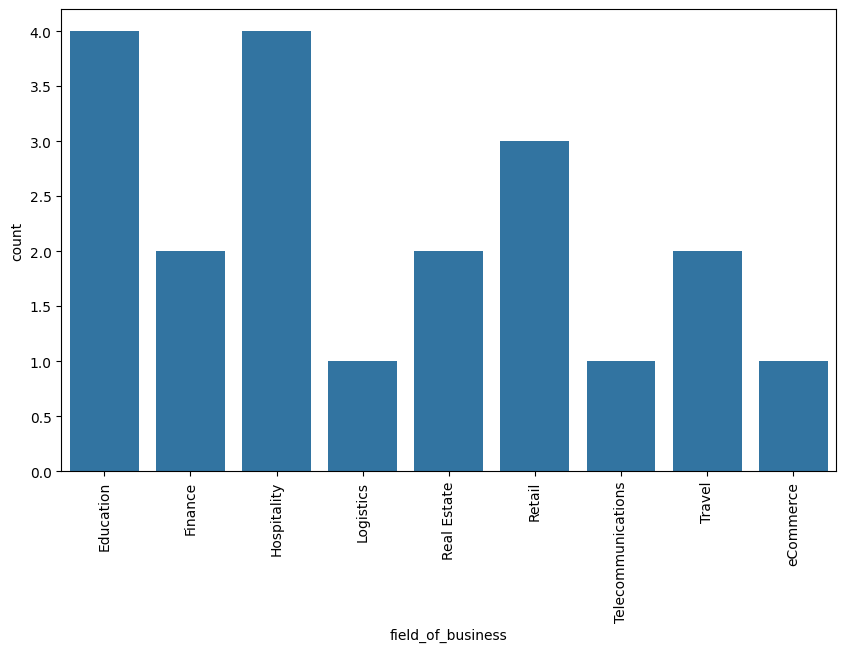

In [18]:
# Detial dan visualisasi field_of_business
print('Customer Business Sector')
print (df_users['field_of_business'].value_counts())
plt.figure(figsize=(10, 6))
sns.countplot(data=df_users, x='field_of_business')
plt.xticks(rotation=90)
plt.show()



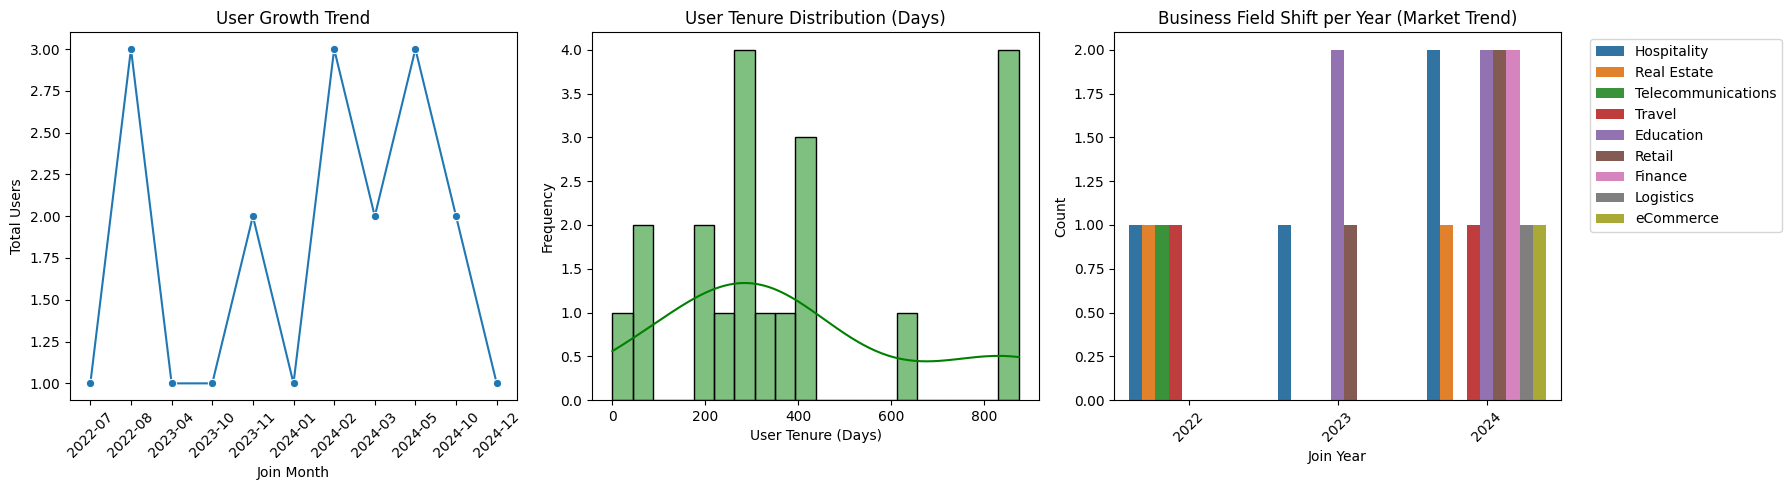

--- Rata-rata Lama Bergabung (Hari) ---
394.8

--- Industri Paling Dominan ---
field_of_business
Education      4
Hospitality    4
Retail         3
Real Estate    2
Name: count, dtype: int64


In [27]:
# User Growth Trend
growth_data = df_users.groupby('join_month').size().reset_index(name='total_users')
growth_data['join_month'] = growth_data['join_month'].astype(str)

plt.figure(figsize=(18,5))
plt.subplot(1,3,1)
sns.lineplot(data=growth_data, x='join_month', y='total_users', marker='o')
plt.title('User Growth Trend')
plt.xticks(rotation=45)
plt.xlabel('Join Month')
plt.ylabel('Total Users')

# User Tenure (Pelanggan/Customer lama)
latest_date = df_users['join_date'].max()
df_users['user_tenure'] = (latest_date - df_users['join_date']).dt.days

plt.subplot(1,3,2)
sns.histplot(df_users['user_tenure'], bins=20, color='green' , kde=True)
plt.title('User Tenure Distribution (Days)')
plt.xlabel('User Tenure (Days)')
plt.ylabel('Frequency')

# Business Field Shift (Market Trend)
df_users['join_year'] = df_users['join_date'].dt.year
business_shift_data = df_users.groupby(['join_year', 'field_of_business']).size().reset_index(name='count')

plt.subplot(1,3,3)
sns.barplot(data=business_shift_data, x='join_year', y='count', hue='field_of_business')
plt.title('Business Field Shift per Year (Market Trend)')
plt.xlabel('Join Year')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.show()

# Print data Summary
print("--- Rata-rata Lama Bergabung (Hari) ---")
print(df_users['user_tenure'].mean())
print("\n--- Industri Paling Dominan ---")
print(df_users['field_of_business'].value_counts().head(4))


In [26]:
# Trend Annual User Growth by Industry
df_users['join_year'] = df_users['join_date'].dt.year
industry_trend = df_users.groupby(['join_year', 'field_of_business']).size().reset_index(name='count')

print("Pergeseran trend industri berdasarkan tahun:")
print(industry_trend)

Pergeseran trend industri berdasarkan tahun:
    join_year   field_of_business  count
0        2022         Hospitality      1
1        2022         Real Estate      1
2        2022  Telecommunications      1
3        2022              Travel      1
4        2023           Education      2
5        2023         Hospitality      1
6        2023              Retail      1
7        2024           Education      2
8        2024             Finance      2
9        2024         Hospitality      2
10       2024           Logistics      1
11       2024         Real Estate      1
12       2024              Retail      2
13       2024              Travel      1
14       2024           eCommerce      1


Musim Regis User per Industry
join_month_name     January  February  March  April  May  June  July  August  \
field_of_business                                                              
Education               0.0       1.0    0.0    0.0  0.0   0.0   0.0     0.0   
Finance                 0.0       0.0    1.0    0.0  0.0   0.0   0.0     0.0   
Hospitality             0.0       1.0    0.0    1.0  1.0   0.0   1.0     0.0   
Logistics               0.0       0.0    0.0    0.0  1.0   0.0   0.0     0.0   
Real Estate             1.0       0.0    0.0    0.0  0.0   0.0   0.0     1.0   
Retail                  0.0       0.0    1.0    0.0  0.0   0.0   0.0     0.0   
Telecommunications      0.0       0.0    0.0    0.0  0.0   0.0   0.0     1.0   
Travel                  0.0       1.0    0.0    0.0  0.0   0.0   0.0     1.0   
eCommerce               0.0       0.0    0.0    0.0  1.0   0.0   0.0     0.0   

join_month_name     September  October  November  December  
field_of_business           

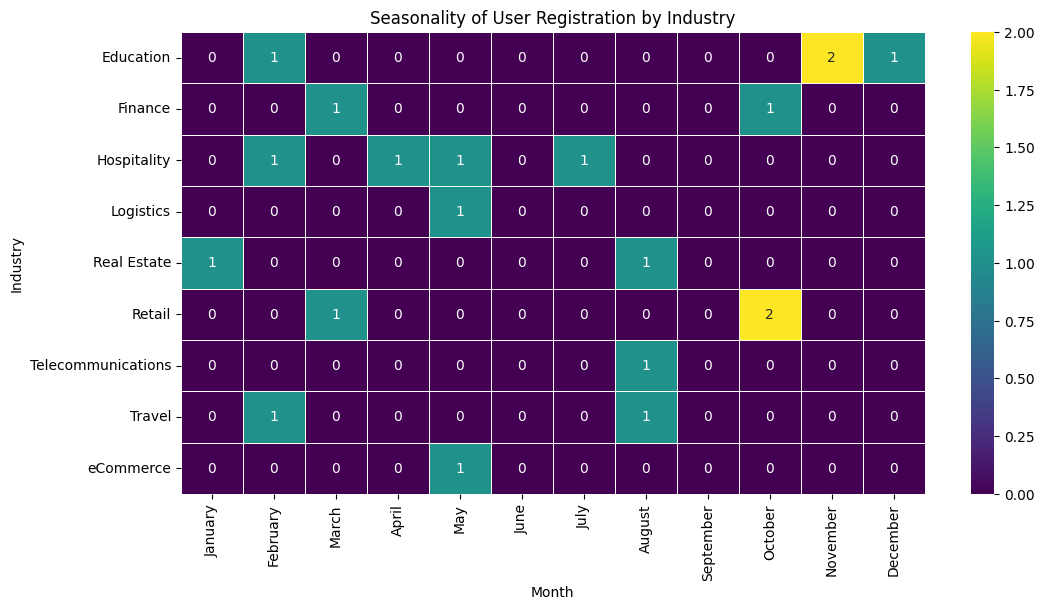

In [44]:
# Seasonality by Industry (Musiman)
df_users['join_month_name'] = df_users['join_date'].dt.month_name()

month_order = ['January', 'February', 'March', 'April', 'May', 'June',
               'July', 'August', 'September', 'October', 'November', 'December']

seasonality = df_users.pivot_table(
    index='field_of_business',
    columns='join_month_name',
    values='user_id',
    aggfunc='count',
    ).reindex(columns=month_order).fillna(0)

print("Musim Regis User per Industry")
print(seasonality)


plt.figure(figsize=(12, 6))
sns.heatmap(seasonality, cmap='viridis', annot=True, fmt='.0f', linewidths=.5)
plt.title('Seasonality of User Registration by Industry')
plt.xlabel('Month')
plt.ylabel('Industry')
plt.show()


 === Industry Velocity (Bertambah User Baru) ====
field_of_business
Finance               2
Retail                1
Hospitality           1
Logistics             1
Real Estate           1
eCommerce             1
Travel                1
Education             0
Telecommunications    0
dtype: int64


/tmp/ipython-input-1224271830.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=velocity_df, x='net_growth', y='field_of_business', palette='YlGnBu')


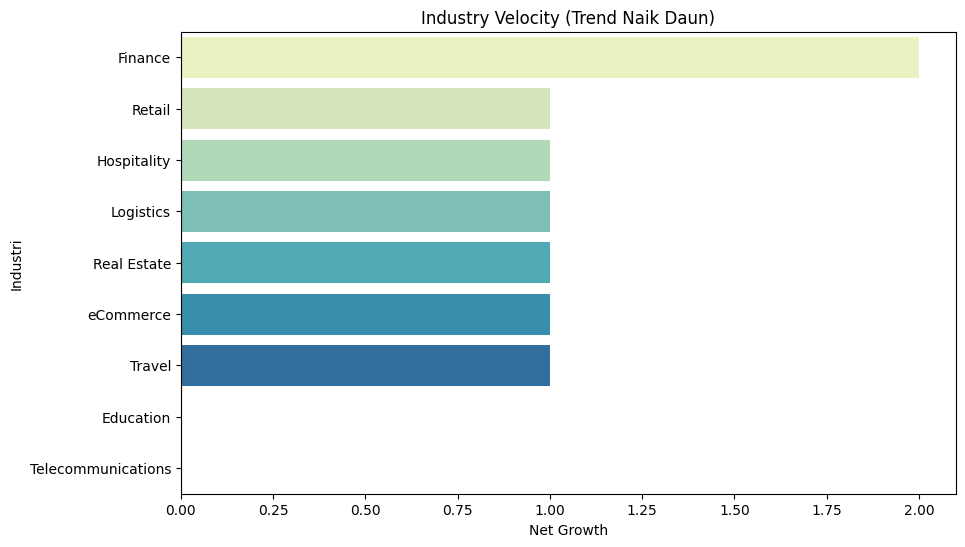

In [46]:
# Industry Velocity - Trend Naik Daun
# (Tahun Terakhir - Tahun Sebelumnya) / Tahun Sebelumnya
df_users['period'] = df_users['join_date'].dt.to_period('Y') #extract Tahunan

# Jumlah user per industri
industry_growth = df_users.groupby(['field_of_business', 'period']).size().unstack(fill_value=0)

last_period = industry_growth.iloc[: , -1] # paling kanan
prev_period = industry_growth.iloc[: , -2] # sebelah kiri

velocity = (last_period - prev_period).sort_values(ascending=False)

print(" === Industry Velocity (Bertambah User Baru) ====")
print(velocity)

# Convert the velocity Series to a DataFrame for plotting
velocity_df = velocity.reset_index(name='net_growth')
velocity_df.columns = ['field_of_business', 'net_growth']

plt.figure(figsize=(10, 6))
sns.barplot(data=velocity_df, x='net_growth', y='field_of_business', palette='YlGnBu')
plt.title('Industry Velocity (Trend Naik Daun)')
plt.xlabel('Net Growth')
plt.ylabel('Industri')
plt.axvline(x=0, color='red', linestyle='--')
plt.show()


In [ ]:
# Dormant Ratio (Customer Tidur/Tidak aktif) (Dormant = Tidak aktif 30 hari)
# Tanggal terkahir transaksi (Recency)


### Summary Insight Table Users

* Total users 20 Customer
* Customer Business Sector terbanyak ada di Education & FInance (4) dan terendah di Logistics, Telecommunications, eCommerce (1)
* Rata - Rata Customer terlama yang bergabung durasi 394.8 hari
* Industri paling dominant Education, Hospitality, and Retail
* Trend industri yang berjalan di tahun 2024 adalah E-commerce
* Aktivitas registrasi sangat jarang, belum ada pola seasonality yang kuat lebih kepada event-based

# Catatan : Unified channel performance reporting

**Background** - each channel is monitored separately, and difficult to understand cross channel performance and user behaviour holistically.
need dashboard unified to support operational and business decision making.



**About us** - OCA Indonesia (by Telkom) operates in the CPaaS industry, empowering businesses to communicate at scale via WhatsApp, SMS, Email, and Voice Call.

**Problem Statement** -  Currently, data is fragmented across different channels. This lack of unified visibility makes it difficult to track Revenue Performance and Delivery Reliability, leading to potential billing inaccuracies and high Churn Risk.

**Objective**
Building a Unified Analytics Dashboard that combines transaction data from all channels (WhatsApp, SMS, Email, Call) to monitor delivery performance (Delivery Rate) and revenue in real-time.

Target Audience :
* C-Level Executives (CEO, CTO, CMO, COO)
* Product Managers of OCA Blast
* Marketing & Campaign Ops (under COO supervision)
* Account Managers (under CMP supervision)

Key Matrics :
* C-Level Executives = Total_Revenue , Revenue per Channel, Total Traffice Volume
* Product Manager =
Global Delivery Rate (success rate) , Failed rate by reason, traffic peak (heatmap)
* Marketing & Campaign Ops =
Cross Channel usage opportunity, Channel effectiveness comparison, Traffic seasonality
* Account Manager =
Top Spenders, User Churn Risk Watchlist,  